# Lab 5: Hyperspectral Data & Water Quality Analysis

Analysis of water quality using airborne hyperspectral and Sentinel-2 satellite data.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import spectral.io.envi as envi
import pandas as pd
from scipy.interpolate import interp1d

print("Libraries imported")

Libraries imported


## 1. Load Hyperspectral Data

In [2]:
data_dir = Path("Obrazy lotnicze")
hdr_files = list(data_dir.glob("*.hdr"))
print(f"Found {len(hdr_files)} datasets")

hdr_path = hdr_files[0]
img = envi.open(str(hdr_path))
metadata = img.metadata
wavelengths = np.array([float(w) for w in metadata['wavelength']])

print(f"Loaded: {hdr_path.name}")
print(f"Dimensions: {img.nrows} × {img.ncols} × {img.nbands}")
print(f"Wavelength range: {wavelengths[0]:.1f} - {wavelengths[-1]:.1f} nm")

Found 3 datasets
Loaded: 221000_Odra_HS_Blok_A_008_VS_join_atm.hdr
Dimensions: 4300 × 2001 × 456
Wavelength range: 414.1 - 2498.9 nm


## 2. False-Color Composites

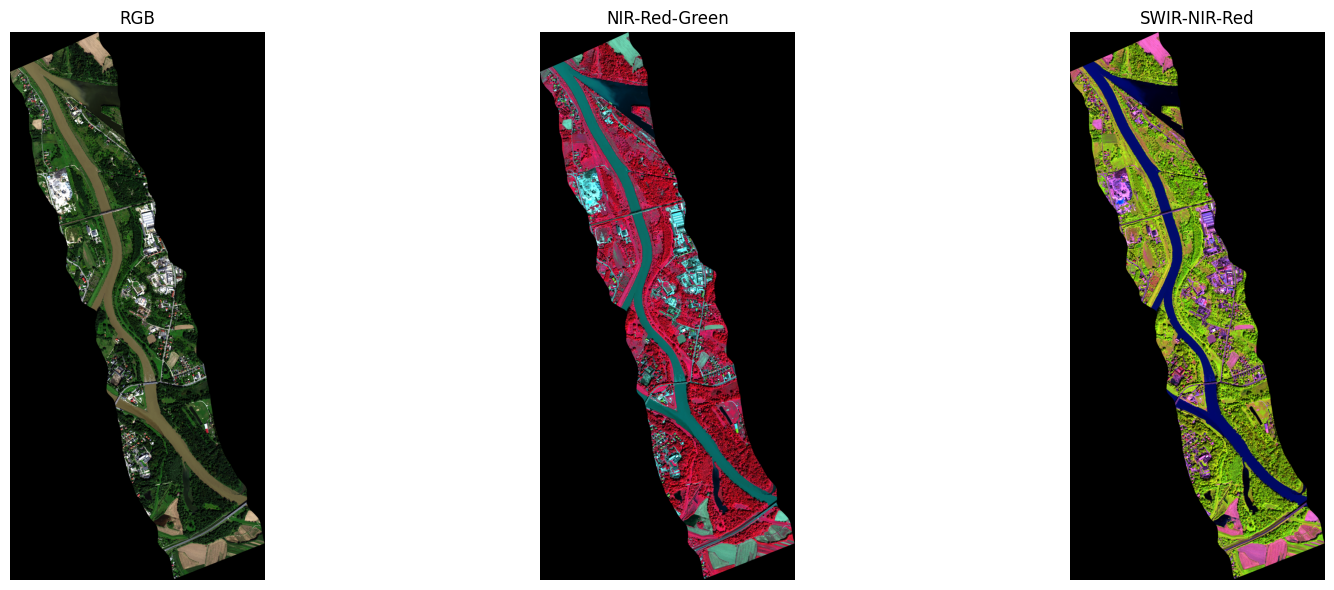

In [3]:
def read_bands_stretched(img, bands, ignore_val=15000):
    rgb = img.read_bands(bands).astype(np.float32)
    rgb[rgb >= ignore_val] = np.nan
    rgb[rgb < 0] = np.nan
    for c in range(3):
        ch = rgb[:, :, c]
        p2, p98 = np.nanpercentile(ch, [2, 98])
        rgb[:, :, c] = np.clip((ch - p2) / max(p98 - p2, 1e-6), 0, 1)
    return np.nan_to_num(rgb, nan=0.0)

def find_band(wls, target):
    return np.argmin(np.abs(wls - target))

# RGB composite
rgb_bands = (74, 45, 18)
rgb = read_bands_stretched(img, rgb_bands)

# False-color composites
nir_r_g = (find_band(wavelengths, 850), find_band(wavelengths, 665), find_band(wavelengths, 560))
swir_nir_r = (find_band(wavelengths, 1600), find_band(wavelengths, 850), find_band(wavelengths, 665))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(rgb)
axes[0].set_title('RGB')
axes[1].imshow(read_bands_stretched(img, nir_r_g))
axes[1].set_title('NIR-Red-Green')
axes[2].imshow(read_bands_stretched(img, swir_nir_r))
axes[2].set_title('SWIR-NIR-Red')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Water Quality Indices

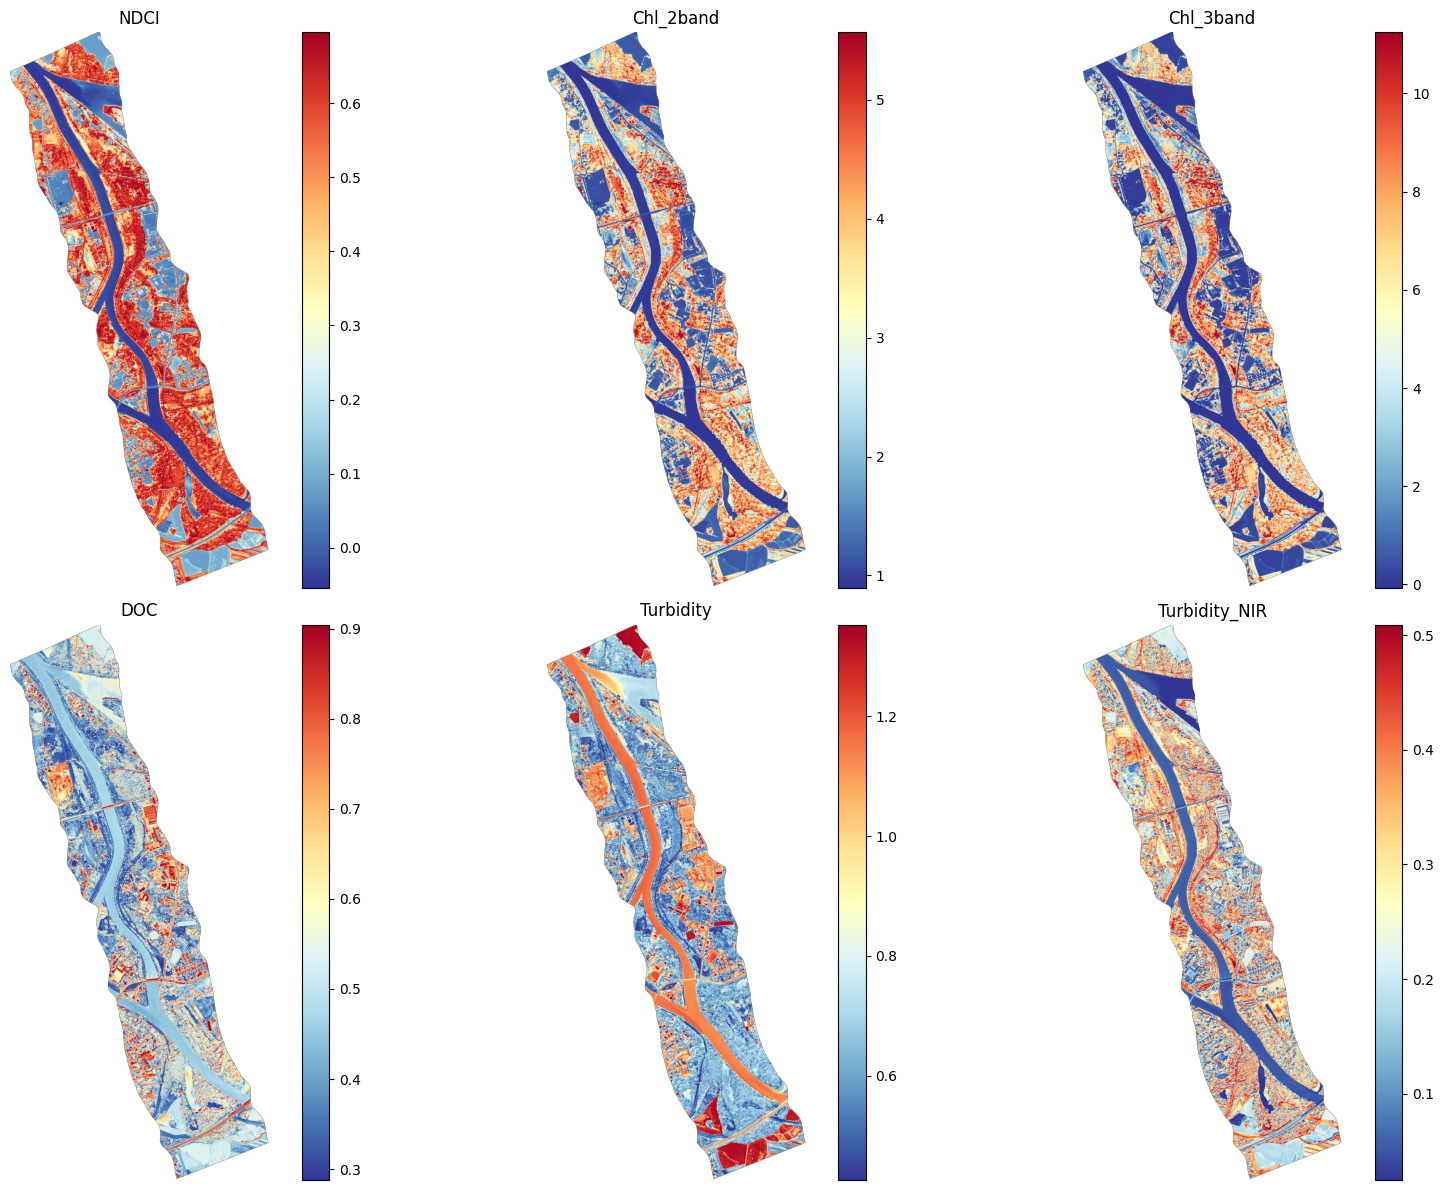

In [4]:
def get_band_data(img, wls, target_wl, ignore_val=15000):
    idx = find_band(wls, target_wl)
    data = img.read_band(idx).astype(np.float32)
    data[data >= ignore_val] = np.nan
    data[data < 0] = np.nan
    return data

# Read required bands
R443 = get_band_data(img, wavelengths, 443)
R490 = get_band_data(img, wavelengths, 490)
R560 = get_band_data(img, wavelengths, 560)
R665 = get_band_data(img, wavelengths, 665)
R705 = get_band_data(img, wavelengths, 705)
R740 = get_band_data(img, wavelengths, 740)
R783 = get_band_data(img, wavelengths, 783)

# Calculate indices
with np.errstate(divide='ignore', invalid='ignore'):
    # Chlorophyll-a
    NDCI = (R705 - R665) / (R705 + R665)
    Chl_2band = R705 / R665
    Chl_3band = (1/R665 - 1/R705) * R740
    
    # DOC
    DOC = R443 / R560
    
    # Turbidity
    Turbidity = R665 / R560
    Turbidity_NIR = R783

# Plot
indices = {'NDCI': NDCI, 'Chl_2band': Chl_2band, 'Chl_3band': Chl_3band,
           'DOC': DOC, 'Turbidity': Turbidity, 'Turbidity_NIR': Turbidity_NIR}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()
for i, (name, data) in enumerate(indices.items()):
    vmin, vmax = np.nanpercentile(data, [2, 98])
    im = axes[i].imshow(data, cmap='RdYlBu_r', vmin=vmin, vmax=vmax)
    axes[i].set_title(name, fontsize=12)
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i], fraction=0.046)
plt.tight_layout()
plt.show()

## 4. Spectral Angle Mapper (SAM)

Loaded reference spectra from data/: water, vegetation, soil, urban
Computing SAM for water...
Computing SAM for vegetation...
Computing SAM for soil...
Computing SAM for urban...


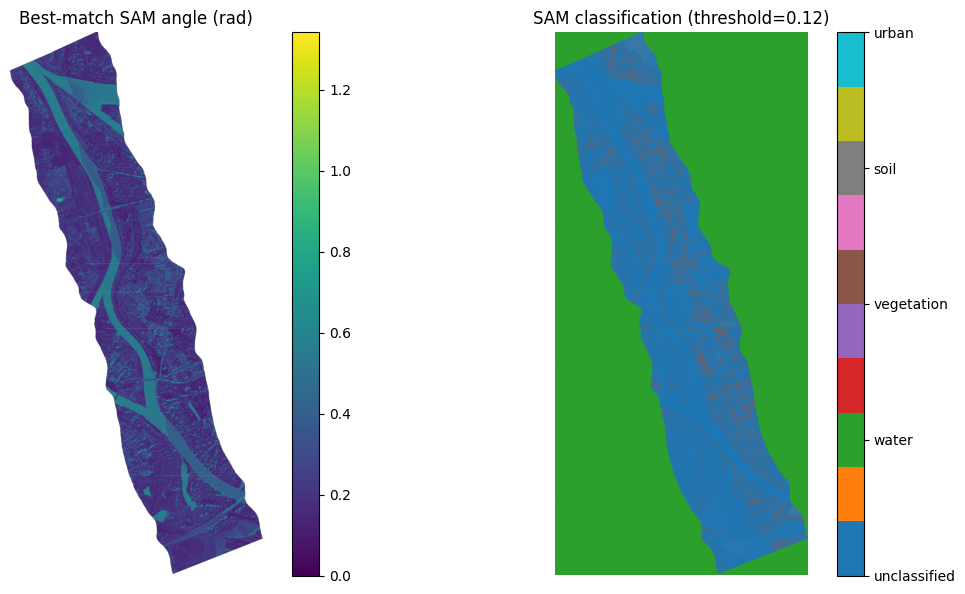

SAM classification completed for: water, vegetation, soil, urban


In [6]:
def spectral_angle_mapper(img, ref_spectrum, wls_ref, wls_img, ignore_val=15000):
    """
    Compute SAM between image and reference spectrum.
    SAM = arccos(dot(spectrum, reference) / (||spectrum|| * ||reference||))
    """
    # Resample reference if needed
    if not np.array_equal(wls_ref, wls_img):
        valid = ~np.isnan(ref_spectrum)
        interp = interp1d(wls_ref[valid], ref_spectrum[valid], 
                         kind='linear', fill_value='extrapolate')
        ref_spectrum = interp(wls_img)
    
    # Load data
    data = img.load().astype(np.float32)
    rows, cols, bands = data.shape
    
    # Mask no-data
    if ignore_val is not None:
        data[data >= ignore_val] = np.nan
    data[data < 0] = np.nan
    
    # Reshape and compute
    spectra = data.reshape((rows * cols, bands))
    dot_prod = np.dot(spectra, ref_spectrum)
    norm_spectra = np.linalg.norm(spectra, axis=1)
    norm_ref = np.linalg.norm(ref_spectrum)
    
    with np.errstate(divide='ignore', invalid='ignore'):
        cos_angle = dot_prod / (norm_spectra * norm_ref)
        cos_angle = np.clip(cos_angle, -1, 1)
        sam = np.arccos(cos_angle)
    
    return sam.reshape((rows, cols))

# Load reference spectra exported from viewer.py (stored in ./data)
from pathlib import Path

def load_reference_csv(csv_path):
    data = np.genfromtxt(csv_path, delimiter=',', names=True)
    x = np.asarray(data[data.dtype.names[0]], dtype=float)
    y = np.asarray(data[data.dtype.names[1]], dtype=float)
    valid = ~np.isnan(y)
    if valid.sum() < 2:
        raise ValueError(f'Not enough valid points in {csv_path}')
    # Keep notebook robust if spectrum length/grid differs slightly
    if len(y) != len(wavelengths):
        y = np.interp(wavelengths, x[valid], y[valid])
    return y

sig_dir = Path('data')
water_ref = load_reference_csv(sig_dir / 'water.csv')
veg_ref = load_reference_csv(sig_dir / 'vegetation.csv')
soil_ref = load_reference_csv(sig_dir / 'soil.csv')

urban_ref = None
urban_path = sig_dir / 'urban.csv'
if urban_path.exists():
    urban_ref = load_reference_csv(urban_path)

print('Loaded reference spectra from data/: water, vegetation, soil' + (', urban' if urban_ref is not None else ''))

# Run SAM and plot outputs
refs = {
    'water': water_ref,
    'vegetation': veg_ref,
    'soil': soil_ref,
}
if urban_ref is not None:
    refs['urban'] = urban_ref

sam_maps = {}
current_ignore_val = 15000
for class_name, ref in refs.items():
    print(f'Computing SAM for {class_name}...')
    sam_maps[class_name] = spectral_angle_mapper(
        img,
        ref,
        wavelengths,
        wavelengths,
        ignore_val=current_ignore_val,
    )

class_names = list(refs.keys())
stack = np.stack([sam_maps[name] for name in class_names], axis=0)
class_idx = np.argmin(stack, axis=0)
min_sam = np.min(stack, axis=0)

# Low SAM angle means better spectral match
threshold = 0.12
class_map = class_idx + 1
class_map[min_sam > threshold] = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

im0 = axes[0].imshow(min_sam, cmap='viridis')
axes[0].set_title('Best-match SAM angle (rad)')
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(class_map, cmap='tab10', vmin=0, vmax=len(class_names))
axes[1].set_title(f'SAM classification (threshold={threshold})')
axes[1].axis('off')
cb = plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
cb.set_ticks(range(len(class_names) + 1))
cb.set_ticklabels(['unclassified'] + class_names)

plt.tight_layout()
plt.show()

print('SAM classification completed for:', ', '.join(class_names))

## 5. Sentinel-2 Integration

In [6]:
# Sentinel-2 band specifications
S2_BANDS = {
    'B2': {'center': 490, 'width': 65},   # Blue
    'B3': {'center': 560, 'width': 35},   # Green
    'B4': {'center': 665, 'width': 30},   # Red
    'B5': {'center': 705, 'width': 15},   # Red Edge 1
    'B6': {'center': 740, 'width': 15},   # Red Edge 2
    'B7': {'center': 783, 'width': 20},   # Red Edge 3
    'B8': {'center': 842, 'width': 115},  # NIR
    'B8A': {'center': 865, 'width': 20},  # NIR narrow
}

def simulate_s2_band(hyperspectral_data, wls, band_spec):
    """Simulate Sentinel-2 band from hyperspectral data."""
    center = band_spec['center']
    width = band_spec['width']
    
    # Gaussian spectral response
    sigma = width / 2.355  # FWHM to sigma
    response = np.exp(-0.5 * ((wls - center) / sigma) ** 2)
    response = response / response.sum()
    
    # Apply response function
    if len(hyperspectral_data.shape) == 3:
        result = np.tensordot(hyperspectral_data, response, axes=([2], [0]))
    else:
        result = np.dot(hyperspectral_data, response)
    
    return result

def calibrate_s2_with_airborne(s2_band, airborne_simulated):
    """Compute calibration coefficients."""
    valid = ~(np.isnan(s2_band) | np.isnan(airborne_simulated))
    if valid.sum() < 100:
        return 1.0, 0.0
    
    x = s2_band[valid].flatten()
    y = airborne_simulated[valid].flatten()
    
    # Linear regression: y = gain * x + offset
    gain = np.cov(x, y)[0, 1] / np.var(x)
    offset = y.mean() - gain * x.mean()
    
    return gain, offset

print("Sentinel-2 calibration functions defined")

Sentinel-2 calibration functions defined


## Summary

This notebook implements:
1. ✓ Hyperspectral data visualization (RGB and false-color)
2. ✓ Water quality indices (Chl-a, DOC, Turbidity)
3. ✓ Spectral Angle Mapper (SAM) classification
4. ✓ Sentinel-2 simulation and calibration

### Next Steps:
- Use `viewer.py` to collect real spectral signatures
- Download Sentinel-2 data using sentinelsat
- Apply calibration to actual Sentinel-2 imagery
- Compare water quality indices between sensors